In [27]:
import operator
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama


In [28]:
model = ChatOllama(
    model="qwen3:4b",
    temperature=0,
)

In [29]:
#  defining class for structured output of the evaluation model
class EvaluationSchema(BaseModel):
    feedback:str =Field(..., description="Detailed Feedback on the essay")
    score :int =Field(..., description="Score out of 10 for the essay",ge =0,le=10)



In [30]:
structure_model = model.with_structured_output(EvaluationSchema)

In [31]:
essay = """Not All Those Who Wander Are Lost

Human life is a journey whose destination is often uncertain. From the moment an individual begins to understand the world, he is expected to choose a direction—what to study, which profession to pursue, whom to marry, where to live and what kind of life to lead. Society often celebrates those who appear to have a clear destination and considers those who change their paths as confused or unsuccessful. However, the statement, “Not all those who wander are lost,” reminds us that a deviation from the conventional path does not necessarily imply a lack of purpose. Sometimes, wandering is itself a process of discovering one's purpose.

At the individual level, wandering may represent exploration. A young person who changes his career after discovering that his initial choice does not suit him is not necessarily wasting time. Similarly, a person who travels, reads different perspectives, interacts with diverse cultures or experiments with different professions may actually be expanding his understanding of himself and the world. The apparent uncertainty may conceal a deeper process of self-discovery. In this sense, wandering is different from aimlessness. The former involves exploration, while the latter involves the absence of direction.

History provides numerous examples of individuals whose journeys did not follow conventional paths. Mahatma Gandhi studied law in London, struggled professionally in India and eventually found his larger purpose through his experiences in South Africa. His seemingly uncertain journey ultimately contributed to the transformation of India's freedom struggle. Dr. A.P.J. Abdul Kalam came from a modest background and began his career in aerospace engineering before becoming a leading scientist and eventually the President of India. His journey demonstrates that one's initial circumstances need not determine one's final destination.

The same principle applies to scientific and technological progress. Many important discoveries have emerged from unexpected observations and failures. Alexander Fleming's discovery of penicillin began with an accidental observation of mould inhibiting bacterial growth. What appeared to be an accident became a milestone in modern medicine. In scientific research, therefore, wandering from the original hypothesis can sometimes lead to a more significant discovery. Progress is not always a straight line; it often involves experimentation, failure and unexpected directions.

At the societal level, wandering can also be a source of social transformation. Established social systems often resist change because they provide familiarity and stability. Reformers, however, question existing assumptions. Raja Ram Mohan Roy challenged social practices such as Sati and advocated modern education. B.R. Ambedkar questioned deeply entrenched structures of social inequality and worked towards constitutional equality and social justice. Their willingness to depart from prevailing social norms was not an act of confusion but an act of purposeful transformation.

Democracy itself benefits from such intellectual wandering. A healthy democracy requires citizens who question policies, institutions and established narratives. If society blindly follows the existing path, it may achieve stability but lose the capacity to correct its mistakes. Dissent, debate and alternative viewpoints therefore act as mechanisms through which society discovers better possibilities. The Constitution of India itself embodies this spirit by combining continuity with change and providing mechanisms for reform.

However, the glorification of wandering must also have limits. Not every deviation is meaningful. In the absence of values, responsibility and a broad sense of purpose, wandering can become escapism. A person who continuously changes goals without learning from experience may remain trapped in indecision. Similarly, a government that constantly changes policies without long-term planning may create uncertainty rather than progress. Therefore, wandering becomes constructive only when it is accompanied by reflection, learning and responsibility.

The distinction between wandering and being lost is therefore important. A traveller may take several roads before reaching the destination, but he remains conscious of what he seeks. Similarly, a student may change academic disciplines, a professional may change careers, or a society may reconsider its institutions. These changes should not automatically be interpreted as failures. What matters is whether the individual or society is learning and moving towards a meaningful objective.

In the Indian context, this idea is particularly relevant for the youth. India has one of the world's largest young populations. The pressure to secure conventional careers, particularly in engineering, medicine, government services and corporate employment, can sometimes discourage experimentation. Education should therefore not merely prepare individuals for existing occupations but also develop curiosity, creativity, critical thinking and the courage to explore new possibilities. Start-ups, research, social entrepreneurship and emerging technologies demonstrate the opportunities available to those willing to take unconventional paths.

At the same time, freedom to explore must be supported by social and economic security. A poor individual may not have the same ability to experiment with careers as someone from a privileged background. Thus, institutions must create an environment where failure does not permanently destroy an individual's opportunities. Accessible education, skilling, social security, credit facilities and employment opportunities can provide the safety net required for constructive experimentation.

The statement also has relevance for public policy. Policymaking takes place in an uncertain environment. Climate change, artificial intelligence, pandemics and geopolitical conflicts create challenges that cannot always be addressed through traditional approaches. Governments must therefore be willing to experiment with new solutions while maintaining accountability. Policies such as India's digital public infrastructure illustrate how unconventional approaches can create large-scale public value when innovation is combined with institutional capacity.

Ultimately, the purpose of life cannot always be understood at the beginning of the journey. A river does not always follow a straight path, yet it eventually reaches the sea. Its curves and deviations are not necessarily signs of failure; they are part of its journey. Similarly, human beings and societies often discover their destination only while travelling.

Therefore, “Not all those who wander are lost” is not an invitation to abandon direction. Rather, it is a reminder that meaningful journeys can contain uncertainty, experimentation and even failure. What matters is to retain a moral compass while remaining open to new roads.

A society that never wanders may never discover a better path, and an individual who never explores may never discover his true potential. The ideal journey, therefore, is neither blind wandering nor rigid certainty, but purposeful exploration guided by values. As long as the traveller continues to learn, reflect and move towards a meaningful destination, the road less travelled may not be a sign of being lost—it may be the very road that leads to discovery."""

In [32]:
prompt = f"""You are an expert essay evaluator. You will be given an essay and you need to evaluate it based on the following criteria: 
1. Clarity of thought
2. Coherence and structure
3. Depth of analysis 
4. assign a score out of 10 based on the overall quality of the essay.  
{essay}"""

# output = structure_model.invoke(prompt)

In [33]:
output.score

9

In [34]:
class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_score: Annotated[list[int],operator.add]  ## this is reducer function
    avg_score :float



In [ ]:
def evluate_language(state:UPSCState)->UPSCState:
    prompt = f"""You are an expert essay evaluator. You will be given an essay and you need to evaluate the language used and provide
    feedback and assign a score out of 10\n{state['essay']}
    """
    output= structure_model.invoke(prompt)
    
    return {'language_feedback':output.feedback,'individual_score':[output.score]}

In [45]:
def evluate_thought(state:UPSCState)->UPSCState:
    prompt = f"""You are an expert essay evaluator. You will be given an essay and you need to evaluate the clarity of thought and provide
    feedback and assign a score out of 10\n{state['essay']}
    """
    output= structure_model.invoke(prompt)
    
    return {'clarity_feedback':output.feedback,'individual_score':[output.score]}

In [46]:
def evluate_analysis(state:UPSCState)->UPSCState:
    prompt = f"""You are an expert essay evaluator. You will be given an essay and you need to evaluate the depth of analysis    and provide
    feedback and assign a score out of 10\n{state['essay']}
    """
    output= structure_model.invoke(prompt)
    
    return {'analysis_feedback':output.feedback,'individual_score':[output.score]}

In [49]:
def final_evaluation(state:UPSCState)->UPSCState:

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_score'])/len(state['individual_score'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}
    

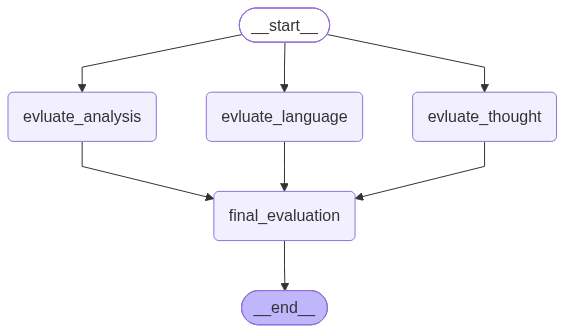

In [52]:
graph = StateGraph(UPSCState)


## define node
graph.add_node("evluate_language",evluate_language)
graph.add_node("evluate_analysis",evluate_analysis)
graph.add_node("evluate_thought",evluate_thought)
graph.add_node("final_evaluation",final_evaluation)
## add edges
graph.add_edge(START,"evluate_language")
graph.add_edge(START,"evluate_analysis")
graph.add_edge(START,"evluate_thought")


graph.add_edge("evluate_language","final_evaluation")
graph.add_edge("evluate_analysis","final_evaluation")
graph.add_edge("evluate_thought","final_evaluation")

graph.add_edge("final_evaluation",END)

workflow = graph.compile()
workflow

In [53]:
initial_state = {
    "essay": essay,
}

output = workflow.invoke(initial_state)

In [54]:
output

{'essay': "Not All Those Who Wander Are Lost\n\nHuman life is a journey whose destination is often uncertain. From the moment an individual begins to understand the world, he is expected to choose a direction—what to study, which profession to pursue, whom to marry, where to live and what kind of life to lead. Society often celebrates those who appear to have a clear destination and considers those who change their paths as confused or unsuccessful. However, the statement, “Not all those who wander are lost,” reminds us that a deviation from the conventional path does not necessarily imply a lack of purpose. Sometimes, wandering is itself a process of discovering one's purpose.\n\nAt the individual level, wandering may represent exploration. A young person who changes his career after discovering that his initial choice does not suit him is not necessarily wasting time. Similarly, a person who travels, reads different perspectives, interacts with diverse cultures or experiments with di